In [1]:
import nibabel as nib
import numpy as np
from skimage.filters import gaussian
from skimage.segmentation import active_contour
from skimage.measure import find_contours
from skimage.draw import polygon
import matplotlib.pyplot as plt
import os

# Example usage:
img_mri = nib.load('./MRI_Brain_T1mprage_1.nii')
img_seg = nib.load('./Segmentation2.nii')

vol_mri = img_mri.get_fdata()  # whole head
vol_seg = img_seg.get_fdata() # manually segmented cerebellum, with ITK-SNAP
vol_mri.shape  # 224,216,288
vol_seg.shape # 224,216,288 --> contains 290 zeros, and 1 one 



(224, 216, 288)

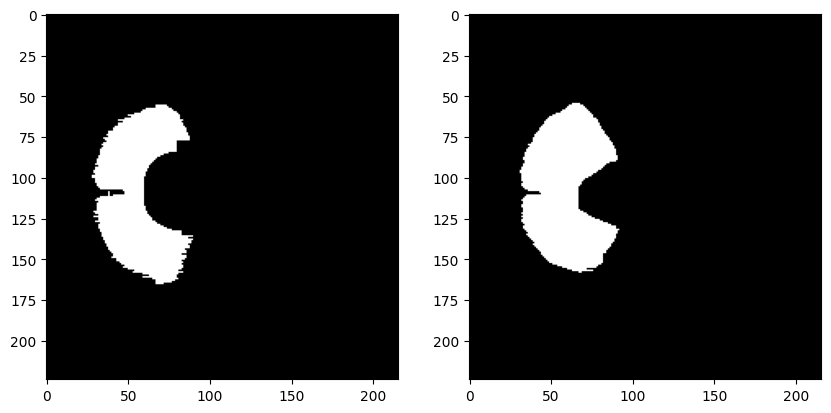

In [2]:
# PRE PROCESSING OF THE DATA
from skimage.morphology import remove_small_objects
from skimage.morphology import binary_closing
from skimage.morphology import remove_small_holes
from skimage.morphology import binary_dilation

vol_binary = vol_seg > 0

## apply operations on the mask
m = remove_small_objects(vol_binary, min_size=5000,connectivity=1)

m = binary_closing(m)

m = remove_small_holes(m,1000,connectivity=1)

# dilatation to make to keep lost parts of the cerebellum
m = binary_dilation(m)


# NOW I WANT TO PRINT IN THE SLICE [;,;,120] THE ORIGINAL SLICE AND THE PRE-PROCESSED SLICE 
fig, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(vol_seg[:,:,130], cmap='gray')
ax[1].imshow(m[:,:,139], cmap='gray')
plt.show()




In [3]:
from skimage.measure import label

# NOW LABLE THE SLICES 
labeled,num = label(m,background=0,return_num=True,connectivity=1)
# there is only one label
# which slices has cerebellum?
slices_with_cerebellum = []
for z in range(labeled.shape[2]):
    sl = labeled[:, :, z]
    if sl.sum() == 0:
        continue
    else:
        slices_with_cerebellum.append(z)
print(num)
print(slices_with_cerebellum)


1
[105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163]


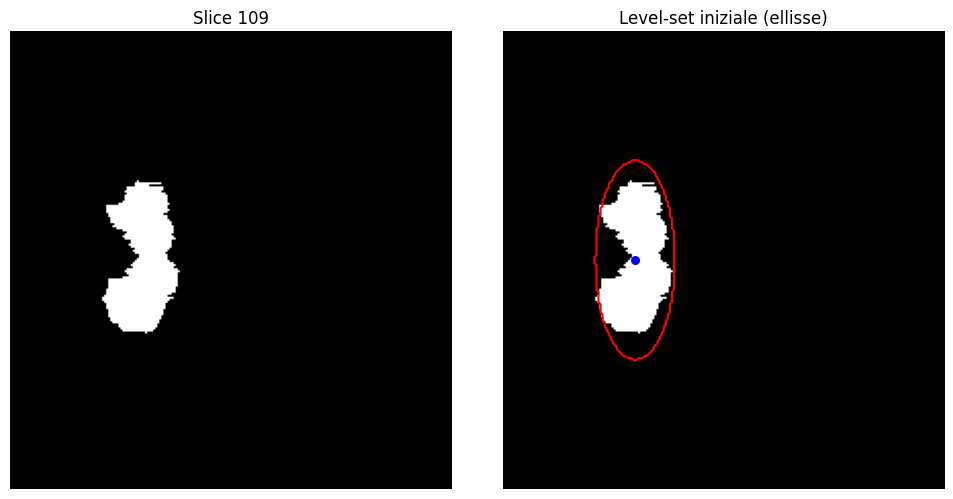

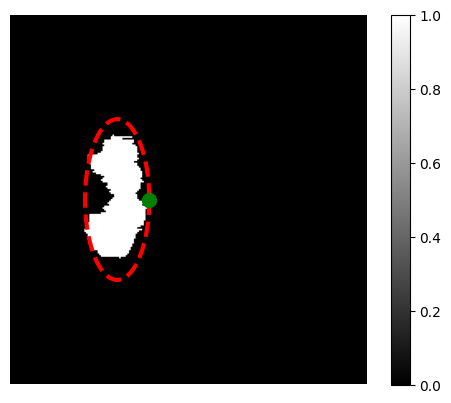

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import regionprops

# 1) Estrai proprietà
slice_idx = 109
props = regionprops(labeled[:, :, slice_idx])
y0 = props[0].centroid[0]                      # centro y
x0 = props[0].centroid[1]                 # centro x (scala se necessario)
major_axis_length = props[0].major_axis_length *1.2
minor_axis_length = props[0].minor_axis_length *1.2

# 2) Semi-assi
ratio = 0.99
radius1 = (major_axis_length / 2.0) * ratio    # semiasse verticale (asse y)
radius2 = (minor_axis_length / 2.0) * ratio    # semiasse orizzontale (asse x)

# 3) Costruisci la level-set dell’ellisse
tmp = m[:, :, slice_idx]
h, w = tmp.shape
Y, X = np.ogrid[:h, :w]
# criterio ellisse: ((y - y0)/radius1)^2 + ((x - x0)/radius2)^2 <= 1
init_ls = (((Y - y0)**2) / radius1**2 + ((X - x0)**2) / radius2**2) <= 1
init_ls = init_ls.astype(float)

# 4) Visualizza immagine e contour
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(tmp, cmap='gray')
axes[0].set_title(f"Slice {slice_idx}")
axes[0].axis('off')

axes[1].imshow(tmp, cmap='gray')
axes[1].contour(init_ls, [0.5], colors='r')
axes[1].scatter([x0], [y0], c='b', s=30)
axes[1].set_title("Level-set iniziale (ellisse)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# 5) (Opzionale) traccia i punti di contorno parametrici
s = np.linspace(0, 2 * np.pi, 400)
r = y0 + radius1 * np.sin(s)
c = x0 + radius2 * np.cos(s)
init_pts = np.vstack([r, c]).T

plt.imshow(tmp, cmap='gray')
plt.plot(init_pts[:, 1], init_pts[:, 0], '--r', lw=3)
plt.plot(init_pts[0, 1], init_pts[0, 0], 'og', markersize=10)   # punto di partenza
plt.colorbar()
plt.axis('off')
plt.show()


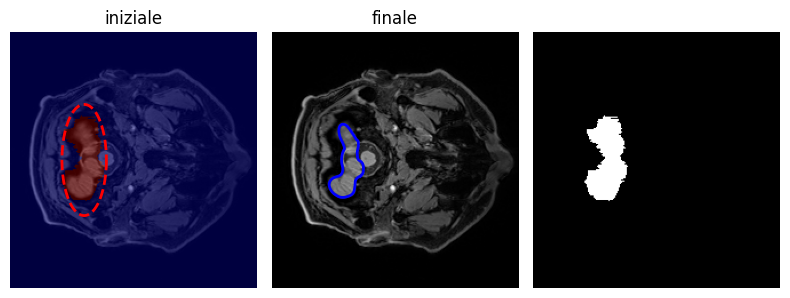

In [5]:
from skimage.filters import gaussian
from skimage.segmentation import inverse_gaussian_gradient, active_contour
import matplotlib.pyplot as plt




img = vol_mri[:, :, slice_idx]
mask = m[:, :, slice_idx].astype(bool)

# 2) azzera tutto ciò che è fuori dalla maschera
img_masked = img.copy()
img_masked[~mask] = 0

# 3) do that onlu inside the mask
img_f = gaussian(img_masked, sigma=2, preserve_range=False)

# 4) calcola l’indicatore di bordo
gimg = inverse_gaussian_gradient(img_f)


snake = active_contour(
    img_f,      # o prova gimg
    init_pts,
    alpha=50,      # elasticità
    beta=50,      # rigidità
    gamma=50,    # passo
    w_edge=1.5,   # forza sul bordo
)

# 4) plottalo
fig, axes = plt.subplots(1,3, figsize=(8,4))
# Primo subplot
axes[0].imshow(vol_mri[:,:,slice_idx], cmap='gray')
axes[0].imshow(m[:,:,slice_idx], cmap='jet', alpha=0.5)  # <-- aggiunto qui sopra il primo
axes[0].plot(init_pts[:,1], init_pts[:,0], 'r--', lw=2)
axes[0].set_title("iniziale")
# Secondo subplot
axes[1].imshow(vol_mri[:,:,slice_idx], cmap='gray')
axes[1].plot(snake[:,1], snake[:,0], 'b-',  lw=2)
axes[1].set_title("finale")
# Terzo subplot
axes[2].imshow(m[:,:,slice_idx], cmap='gray')
# Toglie assi
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

In [6]:
snake_masks = []
# Loop to print all of them
for slice_idx in slices_with_cerebellum:
    props = regionprops(labeled[:, :, slice_idx])
    y0 = props[0].centroid[0]  # center y
    x0 = props[0].centroid[1]  # center x (scale if necessary)
    major_axis_length = props[0].major_axis_length * 1.2
    minor_axis_length = props[0].minor_axis_length * 500

    # 2) Semi-axes
    ratio = 0.99
    radius1 = (major_axis_length / 2.0) * ratio    # vertical semi-axis (y-axis)
    radius2 = (minor_axis_length / 2.0) * ratio    # horizontal semi-axis (x-axis)

    # 3) Build the level-set of the ellipse
    tmp = m[:, :, slice_idx]
    h, w = tmp.shape
    Y, X = np.ogrid[:h, :w]
    # ellipse criterion: ((y - y0)/radius1)^2 + ((x - x0)/radius2)^2 <= 1
    init_ls = (((Y - y0)**2) / radius1**2 + ((X - x0)**2) / radius2**2) <= 1
    init_ls = init_ls.astype(float)
    img = vol_mri[:, :, slice_idx]
    mask = m[:, :, slice_idx].astype(bool)

    # 2) Zero everything outside the mask
    img_masked = img.copy()
    img_masked[~mask] = 0

    # 3) Apply only inside the mask
    img_f = gaussian(img_masked, sigma=2, preserve_range=False)

    # 4) Compute the edge indicator
    gimg = inverse_gaussian_gradient(img_f)

    snake = active_contour(
        img_f,           # or try gimg
        init_pts,
        alpha=50,        # elasticity
        beta=50,         # rigidity
        gamma=50,        # step size
        w_edge=1.5,      # edge attraction strength
    )

    from skimage.draw import polygon2mask

    # Define the shape of the mask (same as the slice shape)
    slice_shape = img_f.shape

    # Create a binary mask from the snake polygon

    snake_mask = polygon2mask(slice_shape, snake)
    snake_masks.append(snake_mask)

masks_volume = np.stack(snake_masks, axis=2)  # shape = (N, H, W)
print(masks_volume.shape)

(224, 216, 59)


In [7]:
import numpy as np
import nibabel as nib
import os, subprocess
import cv2

# 假设 vol_sub, mask_sub 已经是 (H,W,N)，并且 background 已置零
# 先计算一个 minimal bounding box，把 vol_sub & mask_sub 裁成最小矩形
vol_sub  = vol_mri[:, :, slices_with_cerebellum]*masks_volume

# 1) 找出所有 True 的点的 x,y 范围
ys, xs, zs = np.nonzero(masks_volume)
y0, y1 = ys.min(), ys.max()+1
x0, x1 = xs.min(), xs.max()+1

# 2) 裁剪
vol_crop = vol_sub[y0:y1, x0:x1, :]
vol_orig = vol_crop.copy()

# 2.5) 优化后的“降高光/阴影 + 突出白色纹理”增强
enh = np.empty_like(vol_crop, dtype=np.float64)

for z in range(vol_crop.shape[2]):
    img = vol_crop[..., z].astype(np.float32)

    # —— 1) 归一化到 [0,1] ——
    mn, mx = img.min(), img.max()
    if mx > mn:
        norm = (img - mn) / (mx - mn)
    else:
        norm = img * 0.0

    # —— 2) Gamma 校正：提升亮部（gamma < 1） ——
    gamma = 0.8
    norm = np.power(norm, gamma)

    # —— 3) CLAHE：局部对比度增强 ——
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    img8 = np.uint8((norm * 255).clip(0,255))
    cl = clahe.apply(img8) / 255.0  # 恢复到 [0,1]

    # —— 4) Unsharp Mask：锐化细节 ——
    blurred = cv2.GaussianBlur(cl, (0, 0), sigmaX=1.0)
    sharp = cl + 1.5 * (cl - blurred)
    sharp = np.clip(sharp, 0, 1)

    # —— 5) 恢复到原始动态范围 ——
    enh[..., z] = sharp * (mx - mn) + mn


# 2.5.5) 写回 vol_crop，保持 float64 & 相同尺寸
vol_crop = enh

# 3) 写 NIfTI
affine = np.eye(4)
nib.save(nib.Nifti1Image(vol_crop, affine), 'T1_crop.nii.gz')

# 4) 配置 FSL
os.environ['FSLDIR']         = '/Users/enricotuda/fsl'
os.environ['PATH']           = os.path.join(os.environ['FSLDIR'],'bin')+':'+os.environ['PATH']
os.environ['FSLOUTPUTTYPE']  = 'NIFTI_GZ'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.filters import meijering, sato, frangi, hessian

# Define your filters
filters = [
    ("Original",  lambda img: img),
    ("Meijering", lambda img: meijering(img, sigmas=[1], black_ridges=False)),
    ("Sato",      lambda img: sato(img, sigmas=[1], black_ridges=False)),
    ("Frangi",    lambda img: frangi(img, sigmas=[1], black_ridges=False)),
    ("Hessian",   lambda img: hessian(img, sigmas=[1])),
]

def plot_all_slices_vesselness(vol):
    H, W, D = vol.shape
    for z in range(D):
        img = vol[:, :, z]
        n = len(filters)
        fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
        for j, (name, func) in enumerate(filters):
            ax = axes[j]
            ax.imshow(func(img), cmap='gray')
            ax.set_title(name, fontsize=8)
            ax.axis('off')
        plt.suptitle(f"Slice {z+1}/{D}", fontsize=10)
        plt.tight_layout(rect=[0,0,1,0.93])
        plt.show()

# Now call it on your `vol_sub`:
plot_all_slices_vesselness(vol_sub)


In [9]:
import numpy as np
import nibabel as nib
from skimage.filters import hessian

# assume `vol_sub` is your (H,W,D) subvolume and `affine` is the 4×4 affine you want to use

H, W, D = vol_sub.shape

# 1) allocate an empty volume to hold Hessian responses
hess_vol = np.zeros_like(vol_sub, dtype=np.float32)

# 2) loop over slices, compute Hessian, store
for z in range(D):
    img = vol_sub[:, :, z]
    # NOTE: hessian returns a float image same shape as input
    hess_slice = hessian(img, sigmas=[1])
    hess_vol[:, :, z] = hess_slice

# 3) save as NIfTI
#    if you already have a proper affine from your original NIfTI:
#    affine = img_mri.affine
#    otherwise identity:
affine = np.eye(4)
hess_img = nib.Nifti1Image(hess_vol, affine)


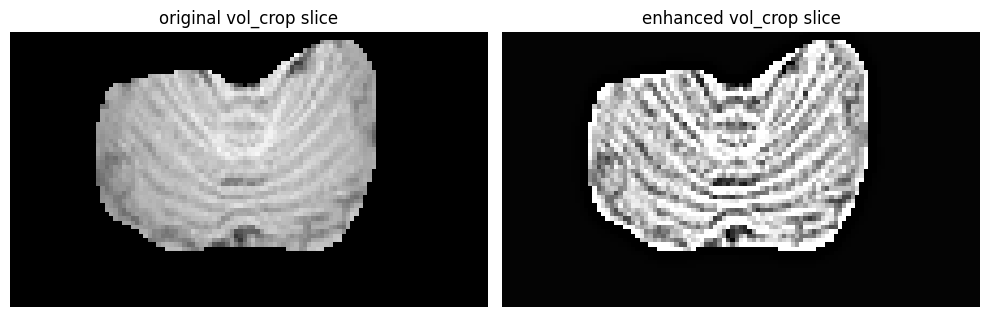

In [10]:
# 选取中间切片
slice_idx = 40
orig_slice = vol_orig[:, :, slice_idx]
proc_slice = vol_crop[:, :, slice_idx]
# 并排绘图
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(np.rot90(orig_slice), cmap='gray')
axes[0].set_title('original vol_crop slice')
axes[0].axis('off')

axes[1].imshow(np.rot90(proc_slice), cmap='gray')
axes[1].set_title('enhanced vol_crop slice')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [11]:
# 5) Run FAST on cropped volume

FAST = os.path.join(os.environ['FSLDIR'],'bin','fast')
subprocess.run([
    FAST,
    '-t', '1',          # T1 模式
    '-n', '5',          # 三分类：CSF/GM/WM
    '-I', '6',          # 偏场校正迭代次数
    '-l', '10',         # MRF 平滑，越大越平滑
    '-H', '0.1',        # 值越大边界越平滑
    '-o', 'fast_crop',   # 输出前缀
    'T1_crop.nii.gz'     # 要分割的 NIfTI 文件
], check=True)

# 6) Load back and pad到原子体积
seg_crop = nib.load('fast_crop_seg.nii.gz').get_fdata().astype(int)
Hc,Wc,_ = vol_crop.shape
H,W,N = vol_sub.shape

seg_sub = np.zeros((H,W,N),int)
seg_sub[y0:y1, x0:x1, :] = seg_crop

# 7) 最终 white_volume
white_volume = (seg_sub==5) & masks_volume
print("white_volume.shape =", white_volume.shape)


white_volume.shape = (224, 216, 59)


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

for i, slice_idx in enumerate(slices_with_cerebellum):
    img        = vol_mri[:, :, slice_idx]
    cereb_mask = masks_volume[:, :, i]
    wm_mask    = white_volume[:, :, i]

    # 1) Cerebellum 掩码裁剪后的原图
    img_cereb = img.copy()
    img_cereb[~cereb_mask] = 0

    # 2) White Matter 掩码裁剪后的原图（不用于 overlay，只演示）
    img_wm = img.copy()
    img_wm[~wm_mask] = 0

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    # 原始影像
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f"Slice {slice_idx}\nOriginal")
    axes[0].axis('off')

    # Cerebellum Mask 裁剪后
    axes[1].imshow(img_cereb, cmap='gray')
    axes[1].set_title("Cerebellum Cropped")
    axes[1].axis('off')

    # White Matter 掩码
    axes[2].imshow(wm_mask, cmap='gray')
    axes[2].set_title("White Matter Mask")
    axes[2].axis('off')

    # Overlay：在 Cerebellum 上叠加红色 WM 区域
    axes[3].imshow(img_cereb, cmap='gray')             # 底图：Cerebellum
    # 叠加红色：WM 区域为红色，alpha 控制透明度
    red_only = ListedColormap([
        (0,0,0,0),   # RGBA: 透明
        (1,0,0,1),   # RGBA: 纯红
    ])
    axes[3].imshow(wm_mask, cmap=red_only, alpha=0.5)
    axes[3].set_title("WM Overlay on Cerebellum")
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1) WM only in the cropped sub-volume
img_wm = np.where(white_volume, vol_sub, 0)  # shape matches (224,216,59)

# 2) Plot every slice in one tall column
H, W, D = img_wm.shape
fig, axes = plt.subplots(D, 1, figsize=(6, 3*D), squeeze=False)

for i in range(D):
    ax = axes[i,0]
    ax.imshow(img_wm[:,:,i], cmap='gray')
    ax.axis('off')
    ax.set_title(f"WM only — slice {i}")

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from skimage.filters import meijering, sato, frangi, hessian

def original(image, **kwargs):
    return image

# 2×9 filter list: (name, function, sigmas)
filters = [
    ("Original",  original,        None),
    ("Meijering", meijering,      [1]),
    ("Meijering", meijering,      range(1,5)),
    ("Sato",      sato,           [1]),
    ("Sato",      sato,           range(1,5)),
    ("Frangi",    frangi,         [1]),
    ("Frangi",    frangi,         range(1,5)),
    ("Hessian",   hessian,        [1]),
    ("Hessian",   hessian,        range(1,5)),
]

H, W, D = img_wm.shape
plt.rcParams["axes.titlesize"] = "small"

for z in range(D):
    slice_img = img_wm[:, :, z]

    # THIS is the fix: use plt.subplots, not Figure.subplots
    fig, axes = plt.subplots(2, len(filters), figsize=(3*len(filters), 5))
    
    for i, black_ridges in enumerate([True, False]):
        for j, (name, func, sigmas) in enumerate(filters):
            ax = axes[i, j]
            if sigmas is None:
                result = func(slice_img)
            else:
                result = func(slice_img, sigmas=sigmas, black_ridges=black_ridges)
            ax.imshow(result, cmap="gray")
            ax.axis("off")

            if i == 0:
                title = name
                if sigmas:
                    title += f"\nσ={list(sigmas)}"
                ax.set_title(title, pad=4)

        # label the rows
        axes[i, 0].set_ylabel(f"black_ridges={black_ridges}", rotation=0, labelpad=40)

    plt.suptitle(f"Vesselness filters on img_wm slice {z}", fontsize=12)
    plt.tight_layout(rect=[0,0,1,0.93])
    plt.show()


In [15]:
# I have the wm in img_wm
# Service functions

from mpl_toolkits.axes_grid1 import make_axes_locatable

# simplify our life for adding colorbars
def add_colorbar(ax,im,fig):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("bottom", size="5%", pad=0.25)
    fig.colorbar(im,  cax=cax, orientation='horizontal')
    
def show_images(img_to_show,slices_to_show):
    n_slices_to_show = len(slices_to_show)
    fig, ax = plt.subplots(1,n_slices_to_show, figsize=(20,6))
    for i in range(n_slices_to_show):
        ax[i].imshow(img_to_show[:,:,slices_to_show[i]])
        ax[i].set_title(str(slices_to_show[i]))
    plt.show()
    

def show_images_with_colorbar(img_to_show,slices_to_show,figsize=(20,7)):
    n_slices_to_show = len(slices_to_show)
    fig, ax = plt.subplots(1,n_slices_to_show, figsize=figsize)
    for i in range(n_slices_to_show):
        im = ax[i].imshow(img_to_show[:,:,slices_to_show[i]])
        ax[i].set_title(str(slices_to_show[i]))
        add_colorbar(ax[i],im,fig)
    plt.show()



In [16]:
img_wm.shape

(224, 216, 59)

In [17]:
from scipy.ndimage import gaussian_filter
# generation of the gaussian of the Laplacian
#sigma = 0.7
sigma = 1.3
d_xx = gaussian_filter(img_wm, sigma=sigma, order=(2,0,0))
d_yy = gaussian_filter(img_wm, sigma=sigma, order=(0,2,0))
d_zz = gaussian_filter(img_wm, sigma=sigma, order=(0,0,2))

laplacian = d_xx + d_yy + d_zz

(224, 216, 59)

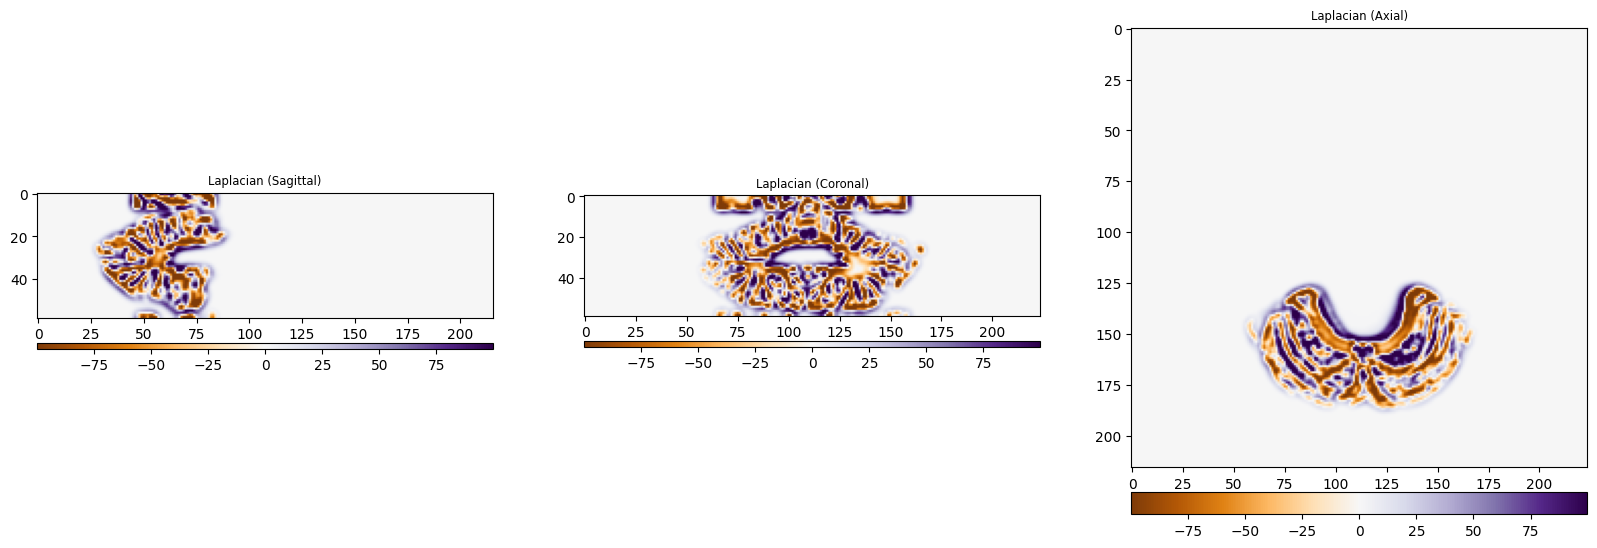

In [18]:
fig, ax = plt.subplots(1,3,figsize=(20,20))

clim = np.percentile(np.abs(laplacian.flatten()),99)

im = ax[0].imshow(laplacian[100,:,:].T[::-1,:],cmap='PuOr',clim=(-clim,clim))
add_colorbar(ax[0],im,fig)
ax[0].set_title('Laplacian (Sagittal)')
im = ax[1].imshow(laplacian[:,70,:].T[::-1,:],cmap='PuOr',clim=(-clim,clim))
add_colorbar(ax[1],im,fig)
ax[1].set_title('Laplacian (Coronal)')
ax[2].imshow(laplacian[:,:,30].T[::-1,::-1],cmap='PuOr',clim=(-clim,clim))
add_colorbar(ax[2],im,fig)
ax[2].set_title('Laplacian (Axial)')

# salva la laplaciana 
affine = img_mri.affine
img = nib.Nifti1Image(laplacian,affine) 
nib.save(img, filename='./LoG_sigma_' + str(sigma) + '.nii.gz')
laplacian.shape

In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter

def compute_FA(vol, sigmas, eps=1e-10, tol=1e-6, clamp=True):
    """
    Compute magnitude‐anisotropy FA at each voxel of `vol` (max over `sigmas`),
    taking abs(eigenvalues), and then optionally clamping to [0,1].
    Raises a ValueError if any unclamped FA > 1+tol.
    """
    H, W, D = vol.shape
    FA_max = np.zeros((H, W, D), dtype=np.float32)

    for s in sigmas:
        # 1) second derivatives
        Hxx = gaussian_filter(vol, sigma=s, order=(2,0,0),mode="reflect")
        Hyy = gaussian_filter(vol, sigma=s, order=(0,2,0),mode="reflect")
        Hzz = gaussian_filter(vol, sigma=s, order=(0,0,2),mode="reflect")
        Hxy = gaussian_filter(vol, sigma=s, order=(1,1,0),mode="reflect")
        Hxz = gaussian_filter(vol, sigma=s, order=(1,0,1),mode="reflect")
        Hyz = gaussian_filter(vol, sigma=s, order=(0,1,1),mode="reflect")

        # 2) build (N,3,3)
        N = H*W*D
        H_stack = np.stack([
            Hxx.ravel(), Hxy.ravel(), Hxz.ravel(),
            Hxy.ravel(), Hyy.ravel(), Hyz.ravel(),
            Hxz.ravel(), Hyz.ravel(), Hzz.ravel()
        ], axis=1).reshape(N,3,3)

        # 3) eigendecompose
        eigs = np.linalg.eigh(H_stack)[0]  # (N,3), ascending
        # take abs so FA ∈ [0,1]
        λ1 = np.abs(eigs[:,2])
        λ2 = np.abs(eigs[:,1])
        λ3 = np.abs(eigs[:,0])

        # 4) FA formula
        μ   = (λ1 + λ2 + λ3) / 3.0
        num = np.sqrt((λ1-μ)**2 + (λ2-μ)**2 + (λ3-μ)**2)
        den = np.sqrt(λ1**2 + λ2**2 + λ3**2) + eps
        FA  = np.sqrt(1.5) * (num / den)

        FA_max = np.maximum(FA_max, FA.reshape(H, W, D))

    # 5) check/clamp
    max_FA = FA_max.max()
    if max_FA > 1.0 + tol:
        if clamp:
            print(f"Warning: unclamped FA max = {max_FA:.3f}, clamping to 1.0")
            FA_max = np.minimum(FA_max, 1.0)
        else:
            raise ValueError(f"FA out of bounds: max FA = {max_FA:.3f} > 1.0")

    return FA_max

# --- usage ---
sigmas = [5]
FA_vol = compute_FA(img_wm, sigmas, clamp=True)


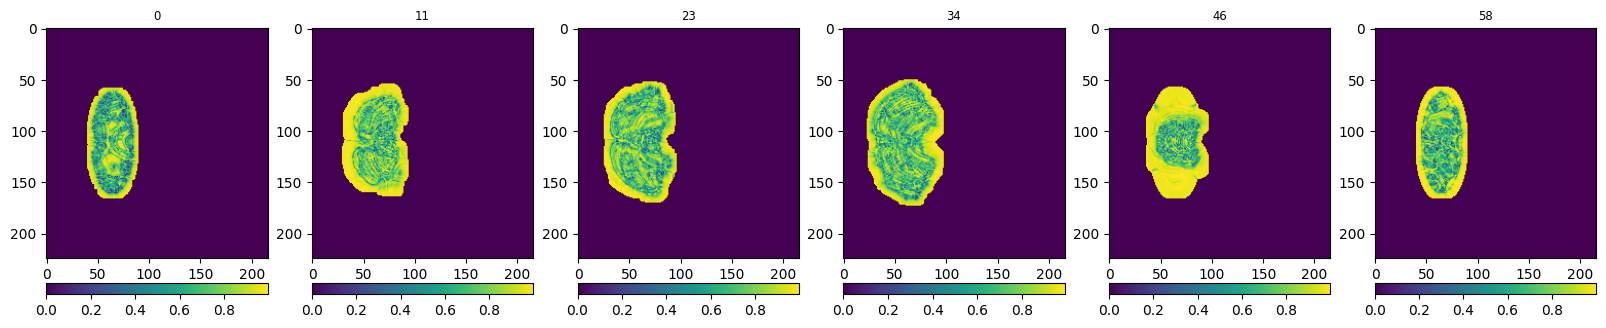

In [59]:
D = FA_vol.shape[2]
slices_to_show = list(np.linspace(0, D-1, 6, dtype=int))

# now call your helper
show_images_with_colorbar(FA_vol, slices_to_show)